# Foot placement estimation

This is the companion notebook for talk on sequential Bayesian learning applied to foot placement estimation.

## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import scipy.interpolate
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

## Get the data

In [2]:
RAW_DATA_PATH = Path("/home/robbin/Datasets/Keep Control/rawdata/sub-pp002/motion/sub-pp002_task-treadmill_tracksys-omc_motion.tsv")
motion_df = pd.read_csv(RAW_DATA_PATH, sep="\t", header=0)
motion_df.head()

,l_toe_POS_x,l_toe_POS_y,l_toe_POS_z,l_toe_POS_err,l_heel_POS_x,l_heel_POS_y,l_heel_POS_z,l_heel_POS_err,l_ank_POS_x,l_ank_POS_y,...,rf_hd_POS_z,rf_hd_POS_err,lb_hd_POS_x,lb_hd_POS_y,lb_hd_POS_z,lb_hd_POS_err,rb_hd_POS_x,rb_hd_POS_y,rb_hd_POS_z,rb_hd_POS_err
0,104.038971,1923.752613,29.210493,1.988046,379.180973,1958.356346,42.749901,2.228772,334.418987,1906.556879,...,1636.228966,1.190804,239.970043,2045.878252,1706.060633,1.890744,270.107025,2193.712363,1679.601374,1.939633
1,104.049532,1923.746053,29.214967,1.984241,379.185322,1958.330570,42.748243,2.218314,334.372779,1906.611620,...,1636.176068,1.169524,240.050710,2045.988794,1706.092758,1.874603,270.154494,2193.748835,1679.541357,1.952618
2,104.037964,1923.741460,29.205850,1.999467,379.202259,1958.330933,42.749620,2.227843,334.386829,1906.554510,...,1636.115574,1.207482,240.077404,2046.087384,1706.161342,1.880366,270.161469,2193.816528,1679.520871,1.970417
3,104.047870,1923.743800,29.218450,1.990330,381.134744,1958.857079,44.447967,1.209415,333.869858,1905.609842,...,1636.075931,1.200377,240.475298,2046.651755,1706.415789,1.515654,266.177106,2197.762651,1681.372945,0.206163
4,104.004976,1923.784626,29.124188,1.984437,381.275087,1958.988360,44.682837,1.196411,333.532319,1906.144652,...,1635.996568,1.214349,240.452243,2046.822281,1706.458181,1.506510,266.115318,2197.910615,1681.396739,0.213725


In [3]:
marker_names = list(set(["_".join(col.split("_")[:-2]) for col in motion_df.columns]))  # get a list of unique marker names

In [4]:
markers_2_segments = {
    "l_foot": ["l_heel", "l_toe", "l_ank"],
    "r_foot": ["r_heel", "r_toe", "r_ank"],
    "l_sk": [f"l_sk{i}" for i in range(1, 5)],
    "r_sk": [f"r_sk{i}" for i in range(1, 5)],
    "pelvis": ["l_psis", "r_psis", "r_asis", "l_asis"],
    "l_th": [f"l_th{i}" for i in range(1, 5)],
    "r_th": [f"r_th{i}" for i in range(1, 5)],
    "head": ["lf_hd", "rf_hd", "rb_hd", "lb_hd"],
    "sternum": [f"m_ster{i}" for i in range(1, 4)],
}

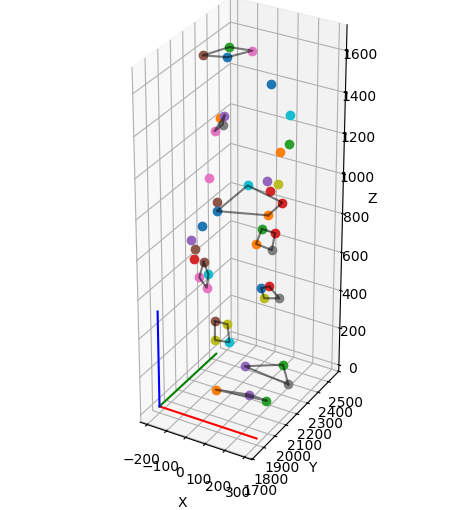

In [5]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot([-200, -200 + 500], [1800, 1800], [0, 0], "r-", label="X")
ax.plot([-200, -200], [1800, 1800 + 500], [0, 0], "g-", label="Y")
ax.plot([-200, -200], [1800, 1800], [0, 500], "b-", label="Z")
for mrk in marker_names:
    ax.plot(
        motion_df[f"{mrk}_POS_x"].median(), 
        motion_df[f"{mrk}_POS_y"].median(), 
        motion_df[f"{mrk}_POS_z"].median(), 
        "o", label=mrk
    )
for seg, mrks in markers_2_segments.items():
    ax.plot(
        [motion_df[f"{mrk}_POS_x"].median() for mrk in mrks] + [motion_df[f"{mrks[0]}_POS_x"].median()],
        [motion_df[f"{mrk}_POS_y"].median() for mrk in mrks] + [motion_df[f"{mrks[0]}_POS_y"].median()],
        [motion_df[f"{mrk}_POS_z"].median() for mrk in mrks] + [motion_df[f"{mrks[0]}_POS_z"].median()],
        "k-", alpha=0.5, label=seg
    )
ax.set_aspect("equal")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
plt.show()

In [6]:
mid_psis = (
    motion_df[["l_psis_POS_x", "l_psis_POS_y", "l_psis_POS_z"]].to_numpy()
    + motion_df[["r_psis_POS_x", "r_psis_POS_y", "r_psis_POS_z"]].to_numpy()
) / 2
yh = motion_df[["l_psis_POS_x", "l_psis_POS_y", "l_psis_POS_z"]].to_numpy() - mid_psis
yh /= np.linalg.norm(yh, axis=1, keepdims=True)
yh

array([[-0.00173305, -0.99997071, -0.0074546 ],
       [-0.00198854, -0.99996949, -0.00755363],
       [-0.00194248, -0.99996887, -0.00764725],
       ...,
       [-0.83400407,  0.55067049, -0.03462981],
       [-0.83616024,  0.5474966 , -0.03291699],
       [-0.83721322,  0.545866  , -0.03323144]], shape=(43022, 3))

In [7]:
zh = np.zeros_like(yh)
zh[:, -1] = 1
zh

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]], shape=(43022, 3))

In [8]:
xh = np.cross(yh, zh)
xh /= np.linalg.norm(xh, axis=1, keepdims=True)
yh = np.cross(zh, xh)
yh /= np.linalg.norm(yh, axis=1, keepdims=True)
xh

array([[-0.9999985 ,  0.0017331 ,  0.        ],
       [-0.99999802,  0.0019886 ,  0.        ],
       [-0.99999811,  0.00194253,  0.        ],
       ...,
       [ 0.55100098,  0.8345046 , -0.        ],
       [ 0.54779346,  0.83661361, -0.        ],
       [ 0.54616766,  0.83767588, -0.        ]], shape=(43022, 3))

In [64]:
# Stack pelvis axes into rotation matrices: shape (num_timesteps, 3, 3)
# Rows are the basic vectors of the pelvis coordinate system: xh, yh, zh
R = np.stack([xh, yh, zh], axis=1)

# Extract the left and right heel markers in the lab frame
r_heel = motion_df[["r_heel_POS_x", "r_heel_POS_y", "r_heel_POS_z"]].to_numpy()
l_heel = motion_df[["l_heel_POS_x", "l_heel_POS_y", "l_heel_POS_z"]].to_numpy()

# Tranlate the heel positions to the pelvis-centered coordinate system,
# then rotate them into the pelvis-aligned coordinate system using the rotation matrices R.
r_heel_pelvis = np.einsum("nij,nj->ni", R, r_heel - mid_psis)
l_heel_pelvis = np.einsum("nij,nj->ni", R, l_heel - mid_psis)

# Same for the toe markers
r_toe = motion_df[["r_toe_POS_x", "r_toe_POS_y", "r_toe_POS_z"]].to_numpy()
l_toe = motion_df[["l_toe_POS_x", "l_toe_POS_y", "l_toe_POS_z"]].to_numpy()
r_toe_pelvis = np.einsum("nij,nj->ni", R, r_toe - mid_psis)
l_toe_pelvis = np.einsum("nij,nj->ni", R, l_toe - mid_psis)


In [40]:
print(f"{R.shape=}")

R.shape=(43022, 3, 3)


In [62]:
# Interpolate missing data
def interpolate_marker_data(marker_data: np.ndarray) -> np.ndarray:
    """Interpolate missing marker data (NaNs) using cubic spline interpolation."""
    t = np.arange(marker_data.shape[0])
    X = marker_data.copy()
    t = t[~np.isnan(X).any(axis=1)]
    X = X[~np.isnan(X).any(axis=1)]
    fn = scipy.interpolate.CubicSpline(x=t, y=X, axis=0)
    return fn(np.arange(marker_data.shape[0]))

r_heel_pelvis_interp = interpolate_marker_data(r_heel_pelvis)
l_heel_pelvis_interp = interpolate_marker_data(l_heel_pelvis)
r_toe_pelvis_interp = interpolate_marker_data(r_toe_pelvis)
l_toe_pelvis_interp = interpolate_marker_data(l_toe_pelvis)
mid_psis_interp = interpolate_marker_data(mid_psis_pelvis)

In [63]:
# Low-pass filter the relative heel and toe positions in the pelvis frame to remove high-frequency noise
fc =   6.  # cutoff frequency in Hz
fs = 200.  # sampling frequency in Hz
order = 4  # filter order
b, a = scipy.signal.butter(order, fc / (fs / 2), btype="low")
r_heel_filt = scipy.signal.filtfilt(b, a, r_heel_pelvis_interp, axis=0, padtype="odd", padlen=3*(max(len(b), len(a)) - 1))
l_heel_filt = scipy.signal.filtfilt(b, a, l_heel_pelvis_interp, axis=0, padtype="odd", padlen=3*(max(len(b), len(a)) - 1))
r_toe_filt = scipy.signal.filtfilt(b, a, r_toe_pelvis_interp, axis=0, padtype="odd", padlen=3*(max(len(b), len(a)) - 1))
l_toe_filt = scipy.signal.filtfilt(b, a, l_toe_pelvis_interp, axis=0, padtype="odd", padlen=3*(max(len(b), len(a)) - 1))
mid_psis_filt = scipy.signal.filtfilt(b, a, mid_psis_interp, axis=0, padtype="odd", padlen=3*(max(len(b), len(a)) - 1))

In [13]:
# Positive peaks in the heel anteroposterior position (x-axis) correspond to heel strikes, negative peaks in the toe anteroposterior position correspond to toe-offs
r_pos_pks, r_pk_props = scipy.signal.find_peaks(r_heel_filt[:, 0], height=r_heel_filt[:,0].mean(), distance=0.5*fs)
r_neg_pks, r_pk_props = scipy.signal.find_peaks(-r_toe_filt[:, 0], height=-r_toe_filt[:,0].mean(), distance=0.5*fs)
l_pos_pks, l_pk_props = scipy.signal.find_peaks(l_heel_filt[:, 0], height=l_heel_filt[:,0].mean(), distance=0.5*fs)
l_neg_pks, l_pk_props = scipy.signal.find_peaks(-l_toe_filt[:, 0], height=-l_toe_filt[:,0].mean(), distance=0.5*fs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=np.arange(len(r_heel_filt)) / fs, y=r_heel_filt[:, 0], mode="lines", name="Right Heel (filtered)"))
fig.add_trace(go.Scatter(x=r_pos_pks / fs, y=r_heel_filt[r_pos_pks, 0], mode="markers", name="Right Heel Strikes"))
fig.add_trace(go.Scatter(x=np.arange(len(r_toe_filt)) / fs, y=r_toe_filt[:, 0], mode="lines", name="Right Toe (filtered)"))
fig.add_trace(go.Scatter(x=r_neg_pks / fs, y=r_toe_filt[r_neg_pks, 0], mode="markers", name="Right Toe Offs"))
fig.add_trace(go.Scatter(x=np.arange(len(l_heel_filt)) / fs, y=l_heel_filt[:, 0], mode="lines", name="Left Heel (filtered)"))
fig.add_trace(go.Scatter(x=l_pos_pks / fs, y=l_heel_filt[l_pos_pks, 0], mode="markers", name="Left Heel Strikes"))
fig.add_trace(go.Scatter(x=np.arange(len(l_toe_filt)) / fs, y=l_toe_filt[:, 0], mode="lines", name="Left Toe (filtered)"))
fig.add_trace(go.Scatter(x=l_neg_pks / fs, y=l_toe_filt[l_neg_pks, 0], mode="markers", name="Left Toe Offs"))
fig.update_layout(yaxis_title="AP position (mm)", xaxis_title="time (s)")
fig.show()

#### Foot placement estimation

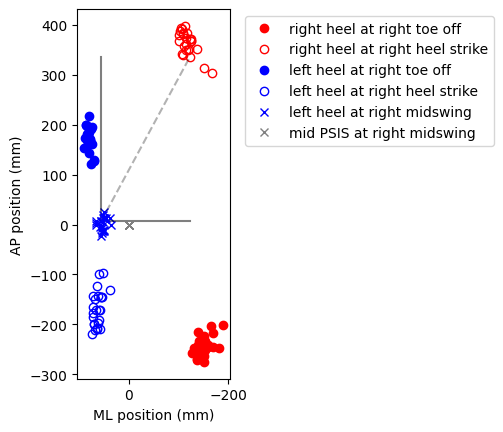

In [65]:
fig, ax = plt.subplots()

# Iterate over the left heel strikes
for idx, l_hs_idx in enumerate(l_pos_pks[:25]):
    # Find the following right toe off
    f = np.argwhere(r_neg_pks > l_hs_idx)[:, 0]
    if len(f) == 0:
        continue
    else:
        r_to_idx = r_neg_pks[f[0]]

    # Find the following heel strike after that toe off
    g = np.argwhere(r_pos_pks > r_to_idx)[:, 0]
    if len(g) == 0:
        continue
    else:
        r_hs_idx = r_pos_pks[g[0]]

    # Determine midswing as halfway between toe off and heel strike
    r_ms_idx = r_to_idx + (r_hs_idx - r_to_idx) // 2
    
    # Compute the distance of the right heel marker at heel strike to the left heel marker at midswing
    r_dist = r_heel_filt[r_hs_idx] - l_heel_filt[r_ms_idx]

    ax.plot(r_heel_filt[r_to_idx, 1], r_heel_filt[r_to_idx, 0], "o", mfc="r", mec="r", label="right heel at right toe off" if idx == 0 else "")
    ax.plot(r_heel_filt[r_hs_idx, 1], r_heel_filt[r_hs_idx, 0], "o", mfc="none", mec="r", label="right heel at right heel strike" if idx == 0 else "")
    ax.plot(l_heel_filt[r_to_idx, 1], l_heel_filt[r_to_idx, 0], "o", mfc="b", mec="b", label="left heel at right toe off" if idx == 0 else "")
    ax.plot(l_heel_filt[r_hs_idx, 1], l_heel_filt[r_hs_idx, 0], "o", mfc="none", mec="b", label="left heel at right heel strike" if idx == 0 else "")
    ax.plot(l_heel_filt[r_ms_idx, 1], l_heel_filt[r_ms_idx, 0], "x", mfc="none", mec="b", label="left heel at right midswing" if idx == 0 else "")
    ax.plot(mid_psis_filt[r_ms_idx, 1], mid_psis_filt[r_ms_idx, 0], "x", mfc="none", mec="gray", label="mid PSIS at right midswing" if idx == 0 else "")

    if idx == 5:
        ax.plot([l_heel_filt[r_ms_idx, 1], r_heel_filt[r_hs_idx, 1]],
                [l_heel_filt[r_ms_idx, 0], r_heel_filt[r_hs_idx, 0]], 
                "k--", alpha=0.3, label="distance at right heel strike" if idx == 0 else "")
        
        # Medio-lateral displacement during right swing phase
        ax.plot([l_heel_filt[r_ms_idx, 1], r_heel_filt[r_hs_idx, 1]],
                [l_heel_filt[r_ms_idx, 0], l_heel_filt[r_ms_idx, 0]], 
                "k-", alpha=0.5, label="distance at right midswing" if idx == 0 else "")
        
        # Anterior-posterior displacement during right swing phase
        ax.plot([l_heel_filt[r_ms_idx, 1], l_heel_filt[r_ms_idx, 1]],
                [l_heel_filt[r_ms_idx, 0], r_heel_filt[r_hs_idx, 0]], 
                "k-", alpha=0.5, label="distance at right heel strike" if idx == 0 else "")
    
ax.xaxis.set_inverted(True)
ax.set_xlabel("ML position (mm)")
ax.set_ylabel("AP position (mm)")
ax.set_aspect("equal")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()
    